In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df=pd.read_csv('cleaned_datasetes_data_science_salaries.csv')
df


,Job_Title,Experience_Level,Employment_Type,Work_Models,Work_Year,Employee_Residence,Salary,Salary_Currency,Company_Location,Company_Size,Salary_Range,Per_Year_Pakage
0,ML Engineer,Entry-level,Part-time,Remote,2020,Germany,14000,EUR,Germany,Small,Low,168000
1,Data Science,Entry-level,Part-time,Hybrid,2024,Germany,15000,EUR,Germany,Medium,Low,180000
2,Data Analyst,Entry-level,Full-time,On-site,2022,Indonesia,15000,USD,Indonesia,Large,Low,180000
3,Business Intelligence Developer,Mid-level,Full-time,Remote,2022,Ghana,15000,USD,Ghana,Medium,Low,180000
4,Machine Learning Developer,Entry-level,Full-time,Remote,2021,Thailand,15000,USD,Thailand,Large,Low,180000
...,...,...,...,...,...,...,...,...,...,...,...,...
6594,Lead Machine Learning Engineer,Senior-level,Full-time,Hybrid,2022,India,7500000,INR,India,Large,High,90000000
6595,ML Engineer,Mid-level,Full-time,Hybrid,2021,Japan,8500000,JPY,Japan,Small,High,102000000
6596,BI Data Analyst,Mid-level,Full-time,Hybrid,2021,Hungary,11000000,HUF,United States,Large,High,132000000
6597,Data Scientist,Mid-level,Full-time,Hybrid,2020,Hungary,11000000,HUF,Hungary,Large,High,132000000


In [4]:
df.head()

,Job_Title,Experience_Level,Employment_Type,Work_Models,Work_Year,Employee_Residence,Salary,Salary_Currency,Company_Location,Company_Size,Salary_Range,Per_Year_Pakage
0,ML Engineer,Entry-level,Part-time,Remote,2020,Germany,14000,EUR,Germany,Small,Low,168000
1,Data Science,Entry-level,Part-time,Hybrid,2024,Germany,15000,EUR,Germany,Medium,Low,180000
2,Data Analyst,Entry-level,Full-time,On-site,2022,Indonesia,15000,USD,Indonesia,Large,Low,180000
3,Business Intelligence Developer,Mid-level,Full-time,Remote,2022,Ghana,15000,USD,Ghana,Medium,Low,180000
4,Machine Learning Developer,Entry-level,Full-time,Remote,2021,Thailand,15000,USD,Thailand,Large,Low,180000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6599 entries, 0 to 6598
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Job_Title           6599 non-null   object
 1   Experience_Level    6599 non-null   object
 2   Employment_Type     6599 non-null   object
 3   Work_Models         6599 non-null   object
 4   Work_Year           6599 non-null   int64 
 5   Employee_Residence  6599 non-null   object
 6   Salary              6599 non-null   int64 
 7   Salary_Currency     6599 non-null   object
 8   Company_Location    6599 non-null   object
 9   Company_Size        6599 non-null   object
 10  Salary_Range        6599 non-null   object
 11  Per_Year_Pakage     6599 non-null   int64 
dtypes: int64(3), object(9)
memory usage: 618.8+ KB


In [7]:
df.describe()

,Work_Year,Salary,Per_Year_Pakage
count,6599.000000,6.599000e+03,6.599000e+03
mean,2022.818457,1.792833e+05,2.151399e+06
std,0.674809,5.263722e+05,6.316467e+06
min,2020.000000,1.400000e+04,1.680000e+05
25%,2023.000000,9.600000e+04,1.152000e+06
50%,2023.000000,1.400000e+05,1.680000e+06
75%,2023.000000,1.875000e+05,2.250000e+06
max,2024.000000,3.040000e+07,3.648000e+08


In [10]:
df.shape

(6599, 12)

# Mean & Median Salary by Role (Job_Title)


In [11]:
salary_by_role = df.groupby("Job_Title")["Salary"].agg(["mean", "median"]).sort_values("mean", ascending=False)
print(salary_by_role.head(10))


                                            mean     median
Job_Title                                                  
Principal Data Architect            3.000000e+06  3000000.0
Head of Machine Learning            2.172667e+06   330000.0
Lead Machine Learning Engineer      1.940250e+06    97500.0
AI Programmer                       8.868010e+05    85000.0
Lead Data Scientist                 8.392368e+05   160434.0
BI Data Analyst                     7.155882e+05    67000.0
Lead Data Analyst                   6.550000e+05   170000.0
Head of Data Science                5.846304e+05   181837.5
Applied Machine Learning Scientist  5.548429e+05    91500.0
Data Integration Specialist         4.649562e+05    92500.0


# 2. Mean Salary by Experience Level

In [12]:
salary_by_exp = df.groupby("Experience_Level")["Salary"].mean().sort_values(ascending=False)
print(salary_by_exp)


Experience_Level
Executive-level    215203.681102
Mid-level          191858.816716
Senior-level       174198.581973
Entry-level        162796.054867
Name: Salary, dtype: float64


# 3. Mean Salary by Location (Employee_Residence)

In [13]:
salary_by_country = df.groupby("Employee_Residence")["Salary"].mean().sort_values(ascending=False)
print(salary_by_country.head(10))


Employee_Residence
Chile        1.525250e+07
Hungary      7.160750e+06
Japan        3.249000e+06
India        1.967420e+06
Israel       1.500000e+06
Norway       9.250000e+05
Thailand     4.787500e+05
Qatar        3.000000e+05
Hong Kong    2.790000e+05
Denmark      2.000000e+05
Name: Salary, dtype: float64


# A. BAR CHART — Average Salary by Role

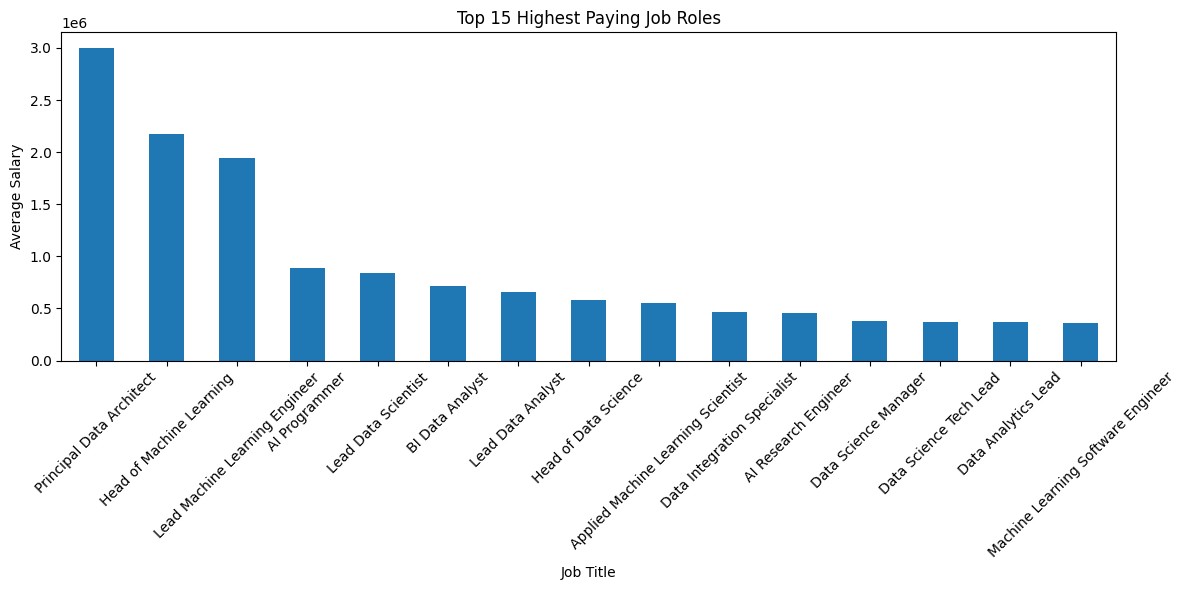

In [17]:
plt.figure(figsize=(12,6))
salary_by_role["mean"].head(15).plot(kind="bar")
plt.title("Top 15 Highest Paying Job Roles")
plt.xlabel("Job Title")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# B. BAR CHART — Average Salary by Experience Level

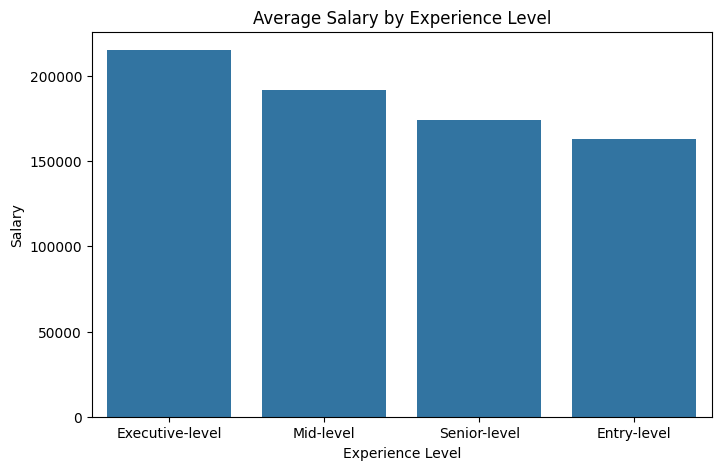

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(x=salary_by_exp.index, y=salary_by_exp.values)
plt.title("Average Salary by Experience Level")
plt.ylabel("Salary")
plt.xlabel("Experience Level")
plt.show()


# C. HEATMAP — Skill vs Experience vs Salary

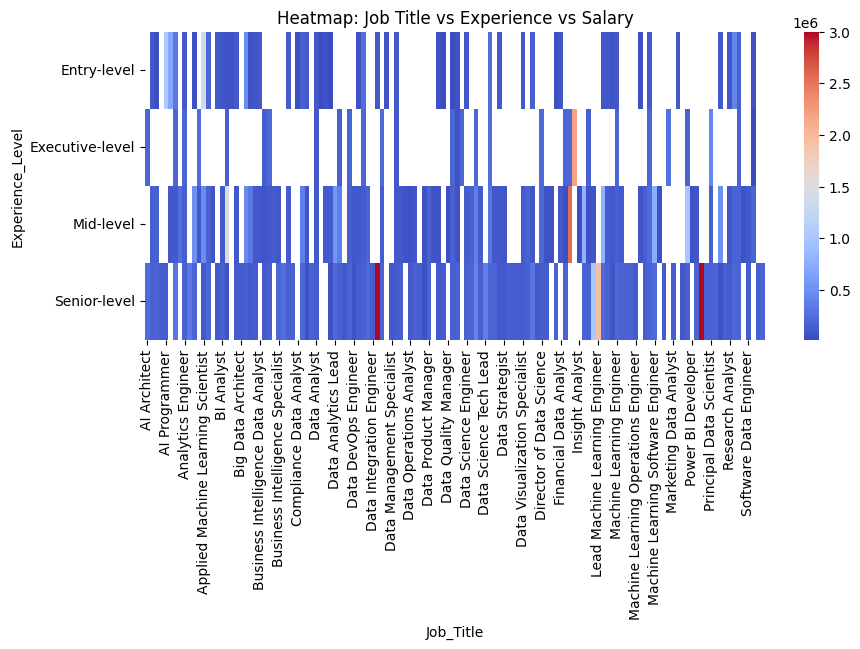

In [23]:
pivot = df.pivot_table(values="Salary",
                       index="Experience_Level",
                       columns="Job_Title",
                       aggfunc="mean")

plt.figure(figsize=(10,4))
sns.heatmap(pivot, cmap="coolwarm")
plt.title("Heatmap: Job Title vs Experience vs Salary")
plt.show()




# D. BUBBLE CHART — Top Paying Skill Clusters

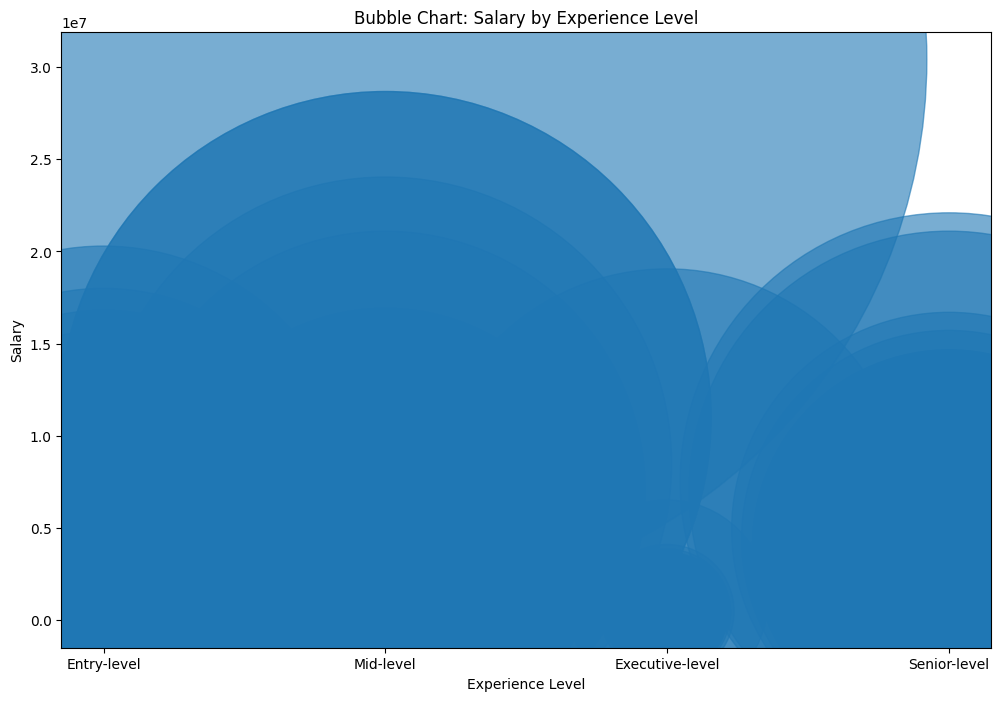

In [26]:
plt.figure(figsize=(12,8))
plt.scatter(df["Experience_Level"], df["Salary"], s=df["Salary"]/50, alpha=0.6)
plt.title("Bubble Chart: Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary")
plt.show()


#  TOP 5 INSIGHTS (Template — You Fill After Results)

In [27]:
top_roles = salary_by_role["mean"].head(5)
print("Top 5 Highest Paying Roles:")
print(top_roles)


Top 5 Highest Paying Roles:
Job_Title
Principal Data Architect          3.000000e+06
Head of Machine Learning          2.172667e+06
Lead Machine Learning Engineer    1.940250e+06
AI Programmer                     8.868010e+05
Lead Data Scientist               8.392368e+05
Name: mean, dtype: float64
